# Unidad 3 · Flujo circular: el programa de envases retornables

**Planta:** Conservas del Itata S.A. — programa de envases retornables
**Datos:** `DatosClases/3_Planificacion/Remanufactura/` — 12 semanas, un solo producto
**Solver:** Gurobi

---

## Qué se decide aquí

Hasta el cuaderno 07 el material entraba a la planta por un solo lado y salía
por el otro. Aquí hay un **segundo flujo, el inverso**, que la planta no
controla: el cliente devuelve envases —*cores*— cuando quiere, en la cantidad
que sea y con la calidad que traigan. Con esos envases se puede armar producto
terminado, pasando por tres procesos: desensamble (D), recuperación de partes
(R) y reensamble (A). La alternativa es comprar un envase nuevo (N).

El modelo decide, semana a semana, cuántos cores **aceptar** —y aceptar es una
decisión con costo, no un dato: se puede rechazar—, cuántos desensamblar,
cuántas partes recuperar, cuánto reensamblar, cuántos envases nuevos comprar
y, si nada de eso alcanza, cuánta venta perder.

## Las tres cosas que hay que mirar

**1. Hay tres inventarios acoplados, no uno.** Cores, partes recuperadas y
producto terminado. Un plan que cuadra en producto terminado puede ser
imposible porque no hay partes, y no hay partes porque no se desensambló a
tiempo. El acoplamiento es la mitad del problema.

**2. El rendimiento $\rho$ multiplica, y multiplica el flujo de hace $L$
períodos.** De cada core que entra al desensamble salen $\rho \approx 0{,}78$
partes utilizables; el resto se pierde como material, no como plata. Y lo que
llega al inventario de partes en la semana $t$ es
$\rho_{t-L}\, u_{t-L}$, con $L = 1$: el desensamble de la semana pasada, **no
el de esta**. Aplicar $\rho$ al período equivocado es el error clásico de este
modelo: cuadra en la planilla y no cuadra en la planta.

**3. El caso de negocio ingenuo se da vuelta.** Y esa vuelta es todo el
ejercicio.

## Cifras de referencia

| resultado | valor |
|---|---|
| costo de remanufactura por envase **procesado** | 3 250 CLP, **−15,6 %** contra el nuevo |
| costo por envase **entregado**, dividiendo TODO por ρ | 4 167 CLP con ρ = 0,78 (**+8,2 %**); 4 190 con el ρ exacto |
| costo por envase **entregado**, dividiendo solo lo que se paga por core que entra | **3 528 CLP** (−8,4 %) — es la fórmula que implementa el modelo |
| techo físico de la circularidad (retornos × ρ / demanda) | **50,1 %** |
| circularidad del plan óptimo sin tope de carbono | **8,3 %** |

Y las cuatro políticas de carbono, todas con **el mismo** presupuesto de
102 161 kg CO₂e:

| política | costo (CLP) | circularidad | CO₂e (kg) |
|---|---|---|---|
| ninguna | 108 887 417 | 8,3 % | 127 702 |
| global | **111 008 862** | 32,5 % | 102 061 |
| rodante (4 sem.) | 113 622 519 | **37,0 %** | 97 142 |
| acumulado | 115 220 635 | 26,5 % | 101 717 |
| por período | **115 752 024** | 26,5 % | 101 717 |

Se cumple el anidamiento del cuaderno 04:
costo(global) ≤ costo(acumulado) ≤ costo(período) y
costo(global) ≤ costo(rodante) ≤ costo(período).

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

hor = pd.read_csv(datos("3_Remanufactura", "itata_reman_horizonte.csv"))
par = pd.read_csv(datos("3_Remanufactura", "itata_reman_parametros.csv")).iloc[0]
proc = pd.read_csv(datos("3_Remanufactura", "itata_reman_procesos.csv")).set_index("proceso")

T = hor.t.astype(int).tolist()
demanda = dict(zip(T, hor.demanda.astype(float)))
retornos = dict(zip(T, hor.retornos.astype(float)))
rendimiento = dict(zip(T, hor.rendimiento.astype(float)))
horas = dict(zip(T, hor.horas_disponibles.astype(float)))
horas_extra_max = dict(zip(T, hor.horas_extra_max.astype(float)))
costo_hora_extra = dict(zip(T, hor.costo_hora_extra_clp.astype(float)))

C_ACEPTAR = float(par.costo_aceptar)
C_DESENS = float(par.costo_desensamble)
C_RECUP = float(par.costo_recuperacion)
C_REENS = float(par.costo_reensamble)
C_NUEVO = float(par.costo_nuevo)
C_DISPOS = float(par.costo_disposicion)
PENAL_PERDIDA = float(par.penal_venta_perdida)
SETUP = {"D": float(par.setup_desensamble), "R": float(par.setup_recuperacion),
         "A": float(par.setup_reensamble)}
ALMACEN = {"C": float(par.almacen_core), "P": float(par.almacen_parte),
           "S": float(par.almacen_producto)}
T_UNIT = {k: float(proc.loc[k, "horas_por_unidad"]) for k in ("D", "R", "A")}
T_SETUP = {k: float(proc.loc[k, "horas_setup"]) for k in ("D", "R", "A")}
EMISION = {k: float(proc.loc[k, "emision_unitaria"]) for k in ("D", "R", "A", "N")}
EMISION["W"] = 0.09                       # descartar un core sin procesar
EMISION_HORA_EXTRA = float(par.emision_hora_extra)
L = int(par.lead_desensamble)
INV0 = {"C": float(par.inv_inicial_core), "P": float(par.inv_inicial_parte),
        "S": float(par.inv_inicial_producto)}

print(hor.to_string(index=False))
print(f"\nlead time del desensamble : L = {L} período(s)")
print(f"inventarios iniciales     : {INV0}")
print(f"\nprocesos:\n{proc.to_string()}")

 t  demanda  retornos  rendimiento  horas_disponibles  horas_extra_max  costo_hora_extra_clp
 1   2400.0      1186       0.6695               30.0              6.0                152000
 2   2664.0      1201       0.7637               30.0              6.0                152000
 3   2857.0      1764       0.7131               30.0              6.0                152000
 4   2928.0      1809       0.7697               30.0              6.0                152000
 5   2857.0      1712       0.7218               30.0              6.0                152000
 6   2664.0      1769       0.8174               30.0              6.0                152000
 7   2400.0      2145       0.6885               30.0              6.0                152000
 8   2136.0      2117       0.9093               25.0              6.0                152000
 9   1943.0      1632       0.8093               30.0              6.0                152000
10   1872.0      1084       0.8382               30.0              6.0

## 1. El caso de negocio ingenuo, y cómo se da vuelta

La presentación con la que se aprueban estos programas es siempre la misma
tabla: *remanufacturar cuesta menos que comprar nuevo*. Y es cierta, si uno
suma los cuatro costos de la cadena circular y los compara con el precio del
envase nuevo.

El problema es la unidad de la comparación. Los 3 250 CLP son el costo de
procesar **un core que entra**. Los 3 850 CLP son el precio de **un envase
que sirve**. No son la misma cosa: de cada core que entra al desensamble solo
salen $\rho$ envases utilizables. Para comparar hay que llevar los dos a
*envase entregado*, y eso significa **dividir por el rendimiento**.

Esa división es todo el ejercicio, y tiene una segunda vuelta que la sección
siguiente desarrolla: **no todos los costos se dividen por $\rho$**, y de
cuáles se dividan depende el signo del resultado.

In [2]:
costo_circular = C_ACEPTAR + C_DESENS + C_RECUP + C_REENS
rho_medio = float((hor.retornos * hor.rendimiento).sum() / hor.retornos.sum())
costo_entregado = costo_circular / rho_medio
RHO_REDONDEADO = 0.78                      # el rho con que se suele citar el caso
costo_entregado_red = costo_circular / RHO_REDONDEADO

caso = pd.DataFrame([
    {"concepto": "aceptar el core", "CLP": C_ACEPTAR},
    {"concepto": "desensamble (D)", "CLP": C_DESENS},
    {"concepto": "recuperación (R)", "CLP": C_RECUP},
    {"concepto": "reensamble (A)", "CLP": C_REENS},
    {"concepto": "TOTAL por core PROCESADO", "CLP": costo_circular},
    {"concepto": "envase nuevo (N)", "CLP": C_NUEVO}])
print(caso.to_string(index=False, float_format=lambda v: f"{v:,.0f}"))

print(f"\nComparación INGENUA, por core procesado:")
print(f"  {costo_circular:,.0f}  contra  {C_NUEVO:,.0f}  ->  "
      f"{100*(costo_circular/C_NUEVO - 1):+.1f} %   (parece buen negocio)")
print(f"\nRendimiento medio ponderado por retornos: rho = {rho_medio:.4f}")
print(f"Comparación CORRECTA, por envase ENTREGADO:")
print(f"  {costo_circular:,.0f} / {rho_medio:.3f} = {costo_entregado:,.0f}  "
      f"contra  {C_NUEVO:,.0f}  ->  "
      f"{100*(costo_entregado/C_NUEVO - 1):+.1f} %   (deja de serlo)")
print(f"\n(con el rho redondeado a {RHO_REDONDEADO:.2f} con que se suele citar el caso, "
      f"{costo_entregado_red:,.0f} CLP,")
print(f" o sea {100*(costo_entregado_red/C_NUEVO - 1):+.1f} %: dos centésimas de rho mueven la cifra en "
      f"{abs(costo_entregado - costo_entregado_red):,.0f} CLP,")
print(" y no cambian la conclusión. Conviene igual saber de dónde sale cada número.)")
print("\nEl mismo dato, dos unidades, dos signos.")

                concepto   CLP
         aceptar el core   320
         desensamble (D)   640
        recuperación (R)   890
          reensamble (A) 1,400
TOTAL por core PROCESADO 3,250
        envase nuevo (N) 3,850

Comparación INGENUA, por core procesado:
  3,250  contra  3,850  ->  -15.6 %   (parece buen negocio)

Rendimiento medio ponderado por retornos: rho = 0.7757
Comparación CORRECTA, por envase ENTREGADO:
  3,250 / 0.776 = 4,190  contra  3,850  ->  +8.8 %   (deja de serlo)

(con el rho redondeado a 0.78 con que se suele citar el caso, 4,167 CLP,
 o sea +8.2 %: dos centésimas de rho mueven la cifra en 23 CLP,
 y no cambian la conclusión. Conviene igual saber de dónde sale cada número.)

El mismo dato, dos unidades, dos signos.


### La segunda vuelta: dónde ocurre la pérdida

La cuenta de arriba divide **los cuatro** costos por $\rho$. Eso supone que
los cuatro se pagan por *core que entra*, es decir, que también se recupera y
se reensambla el material que después resulta inservible. No es lo que dice el
proceso, y —lo que importa más— **no es lo que dice el modelo**: en el balance
de partes el rendimiento se aplica al salir del desensamble, de modo que la
recuperación ($v_t$) y el reensamble ($x_t$) operan ya sobre las $\rho$
unidades buenas. Aceptar y desensamblar, en cambio, sí se pagan por core que
entra. El costo por envase entregado que corresponde al modelo es

$$c(\rho) = \frac{c_{\text{aceptar}} + c_{\text{desens}}}{\rho}
           + c_{\text{recup}} + c_{\text{reens}}$$

y da un número bastante distinto. **Las dos cuentas son correctas para dos
procesos distintos**, y elegir entre ellas no es aritmética: es ir a preguntar
en qué punto de la línea se descarta el material. Si el descarte se detecta al
desensamblar, vale la fórmula de arriba; si recién aparece después de
recuperar y reensamblar —porque el defecto se descubre en la prueba final—
vale la otra, y el programa deja de convenir.

In [3]:
rho_critico = (C_ACEPTAR + C_DESENS) / (C_NUEVO - C_RECUP - C_REENS)
print("costo por envase ENTREGADO, según dónde ocurra la pérdida:\n")
print(f"{'rho':>8}  {'todo / rho':>12}  {'por etapas':>12}   (vs. envase nuevo)")
for r_ in (0.65, 0.70, rho_medio, 0.85, 0.9093, 1.00):
    c_todo = costo_circular / r_
    c_eta = (C_ACEPTAR + C_DESENS) / r_ + C_RECUP + C_REENS
    print(f"{r_:8.4f}  {c_todo:>12,.0f}  {c_eta:>12,.0f}    "
          f"{100*(c_todo/C_NUEVO - 1):+6.1f} %  /  {100*(c_eta/C_NUEVO - 1):+6.1f} %")
print(f"\nprecio del envase nuevo: {C_NUEVO:,.0f} CLP")
print(f"rendimiento crítico de la fórmula por etapas: rho* = {rho_critico:.4f}")
print(f"rendimiento crítico de la fórmula 'todo / rho': "
      f"rho* = {costo_circular/C_NUEVO:.4f}")
n_etapas = int((hor.rendimiento >= rho_critico).sum())
n_todo = int((hor.rendimiento >= costo_circular / C_NUEVO).sum())
print(f"\nEl horizonte tiene rho entre {hor.rendimiento.min():.4f} y "
      f"{hor.rendimiento.max():.4f}.")
print(f"semanas en que conviene remanufacturar, fórmula por etapas : "
      f"{n_etapas:2d} de {len(T)}")
print(f"semanas en que conviene remanufacturar, fórmula 'todo / rho': "
      f"{n_todo:2d} de {len(T)}")
print("La misma planta, los mismos datos, y dos recomendaciones opuestas: con")
print("una fórmula el programa conviene todo el año, con la otra casi nunca.")
print("\nEste cuaderno usa la formulación POR ETAPAS, porque es la que el modelo")
print("implementa. La sección 4 muestra que, aun con el margen a favor, la")
print("circularidad del plan óptimo llega apenas al 8 %: el margen unitario NO")
print("es lo que limita este programa.")

costo por envase ENTREGADO, según dónde ocurra la pérdida:

     rho    todo / rho    por etapas   (vs. envase nuevo)
  0.6500         5,000         3,767     +29.9 %  /    -2.2 %
  0.7000         4,643         3,661     +20.6 %  /    -4.9 %
  0.7757         4,190         3,528      +8.8 %  /    -8.4 %
  0.8500         3,824         3,419      -0.7 %  /   -11.2 %
  0.9093         3,574         3,346      -7.2 %  /   -13.1 %
  1.0000         3,250         3,250     -15.6 %  /   -15.6 %

precio del envase nuevo: 3,850 CLP
rendimiento crítico de la fórmula por etapas: rho* = 0.6154
rendimiento crítico de la fórmula 'todo / rho': rho* = 0.8442

El horizonte tiene rho entre 0.6695 y 0.9093.
semanas en que conviene remanufacturar, fórmula por etapas : 12 de 12
semanas en que conviene remanufacturar, fórmula 'todo / rho':  2 de 12
La misma planta, los mismos datos, y dos recomendaciones opuestas: con
una fórmula el programa conviene todo el año, con la otra casi nunca.

Este cuaderno usa la f

## 2. El techo físico de la circularidad, antes de optimizar

Antes de resolver nada conviene calcular cuánta demanda **podría** cubrirse
con material recuperado si todo saliera perfecto: si se aceptaran todos los
retornos, se desensamblaran todos, se recuperara todo lo recuperable y no
hubiera ni una restricción de capacidad, de carbono o de costo.

$$\text{techo} = \frac{\sum_t \rho_t\, R_t}{\sum_t d_t}$$

Este número **no depende del modelo**: es aritmética sobre los datos. Y es la
respuesta a la pregunta que siempre aparece en la presentación de gerencia
—"¿y no podríamos llegar al 80 % de circularidad?"—. No se puede, no por falta
de voluntad ni de presupuesto ni de un impuesto al carbono más alto, sino
porque **no hay más material**. Ninguna política puede pasar de ahí.

In [4]:
retorno_total = sum(retornos.values())
demanda_total = sum(demanda.values())
material_util = sum(rendimiento[t] * retornos[t] for t in T)
techo = material_util / demanda_total

print(f"demanda del horizonte              : {demanda_total:>10,.0f} envases")
print(f"cores que vuelven                  : {retorno_total:>10,.0f} "
      f"({100*retorno_total/demanda_total:.1f} % de la demanda)")
print(f"partes utilizables (retornos x rho): {material_util:>10,.0f}")
print(f"\nTECHO FISICO DE LA CIRCULARIDAD    : {100*techo:>9.1f} %")
print("\nY ese techo supone aceptar el 100 % de los retornos, desensamblarlos")
print("todos, recuperar todo lo recuperable y no tener ninguna restricción de")
print("capacidad ni de lead time. Es una cota, no una meta.")

demanda del horizonte              :     28,800 envases
cores que vuelven                  :     18,591 (64.6 % de la demanda)
partes utilizables (retornos x rho):     14,420

TECHO FISICO DE LA CIRCULARIDAD    :      50.1 %

Y ese techo supone aceptar el 100 % de los retornos, desensamblarlos
todos, recuperar todo lo recuperable y no tener ninguna restricción de
capacidad ni de lead time. Es una cota, no una meta.


## 3. El modelo

**Variables** (todas por período $t$, todas continuas salvo los tres setups):

| | | | |
|---|---|---|---|
| $a_t$ cores aceptados | $w_t$ cores descartados | $u_t$ desensamblados | $v_t$ partes recuperadas |
| $x_t$ producto reensamblado | $m_t$ envases nuevos | $l_t$ venta perdida | $o_t$ horas extra |
| $C_t$ inventario de cores | $P_t$ inventario de partes | $S_t$ inventario de producto | $y^D_t, y^R_t, y^A_t$ setups |

**Los tres balances**, que son el corazón del modelo:

$$C_t = C_{t-1} + a_t - u_t - w_t$$
$$P_t = P_{t-1} + \rho_{t-L}\, u_{t-L} - v_t$$
$$S_t = S_{t-1} + x_t + m_t - d_t + l_t$$

El segundo es el que hay que leer dos veces. El rendimiento **multiplica** el
desensamble hecho $L$ períodos antes. Dos errores habituales, los dos
silenciosos:

* escribir $\rho_t\, u_t$ (rendimiento del período actual): el plan supone que
  las partes están disponibles el mismo día en que entra el core;
* escribir $\rho_t\, u_{t-L}$ (rendimiento del período de llegada en vez del
  de entrada): el plan usa el rendimiento de un lote que todavía no se
  procesa.

Ninguno de los dos produce error ni infactibilidad. Producen un plan que la
planta no puede ejecutar.

**Dos restricciones de coherencia** que parecen obvias y que hay que escribir:
$x_t \le v_t$ (no se reensambla lo que no se recuperó) y $a_t \le R_t$ (no se
acepta más de lo que vuelve). Y una de cierre de horizonte: $u_t = 0$ en los
últimos $L$ períodos, porque esas partes llegarían después del final y el
modelo, si no, desensamblaría gratis para nada.

**La capacidad es compartida.** Los tres procesos compiten por las mismas
horas de la nave, así que desensamblar en una semana le quita horas al
reensamble de esa misma semana. Es el acoplamiento que vuelve no trivial la
decisión de *cuándo* hacer cada cosa.

In [5]:
def reman(politica="ninguna", presupuesto=None, ventana=4,
          lead_time=True, tiempo_limite=180.0, gap=1e-4):
    """Flujo circular de 12 semanas, con una de las cuatro políticas de carbono."""
    LL = L if lead_time else 0
    m = gp.Model(f"REMAN-{politica}")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = gap
    m.Params.Seed = 0

    a = m.addVars(T, lb=0.0, name="aceptar")
    w = m.addVars(T, lb=0.0, name="descartar")
    u = m.addVars(T, lb=0.0, name="desensamblar")
    v = m.addVars(T, lb=0.0, name="recuperar")
    x = m.addVars(T, lb=0.0, name="reensamblar")
    mm = m.addVars(T, lb=0.0, name="nuevo")
    C = m.addVars(T, lb=0.0, name="invCore")
    P = m.addVars(T, lb=0.0, name="invParte")
    S = m.addVars(T, lb=0.0, name="invProducto")
    l = m.addVars(T, lb=0.0, name="ventaPerdida")
    yD = m.addVars(T, vtype=GRB.BINARY, name="yD")
    yR = m.addVars(T, vtype=GRB.BINARY, name="yR")
    yA = m.addVars(T, vtype=GRB.BINARY, name="yA")
    o = m.addVars(T, lb=0.0, name="horasExtra")

    # big-M por proceso: no tiene sentido procesar más cores de los que pueden
    # llegar en todo el horizonte, ni producir más que la demanda total.
    M_core = sum(retornos.values()) + INV0["C"]
    M_prod = sum(demanda.values()) + INV0["S"]

    for k, t in enumerate(T):
        prevC = INV0["C"] if k == 0 else C[T[k - 1]]
        prevP = INV0["P"] if k == 0 else P[T[k - 1]]
        prevS = INV0["S"] if k == 0 else S[T[k - 1]]

        m.addConstr(prevC + a[t] - u[t] - w[t] == C[t], name=f"balCore[{t}]")

        kk = k - LL                      # el desensamble que entró hace L
        llega = rendimiento[T[kk]] * u[T[kk]] if kk >= 0 else 0.0
        m.addConstr(prevP + llega - v[t] == P[t], name=f"balParte[{t}]")

        m.addConstr(prevS + x[t] + mm[t] - demanda[t] + l[t] == S[t],
                    name=f"balProducto[{t}]")

        m.addConstr(x[t] <= v[t], name=f"reensamble_acotado[{t}]")
        m.addConstr(a[t] <= retornos[t], name=f"oferta[{t}]")

        m.addConstr(u[t] <= M_core * yD[t], name=f"enlD[{t}]")
        m.addConstr(v[t] <= M_core * yR[t], name=f"enlR[{t}]")
        m.addConstr(x[t] <= M_prod * yA[t], name=f"enlA[{t}]")

        carga = (T_UNIT["D"] * u[t] + T_UNIT["R"] * v[t] + T_UNIT["A"] * x[t]
                 + T_SETUP["D"] * yD[t] + T_SETUP["R"] * yR[t]
                 + T_SETUP["A"] * yA[t])
        m.addConstr(carga <= horas[t] + o[t], name=f"cap[{t}]")
        m.addConstr(o[t] <= horas_extra_max[t], name=f"omax[{t}]")

    # lo desensamblado en los ultimos L periodos llegaria fuera del horizonte
    for k in range(len(T) - LL, len(T)):
        if LL > 0 and k >= 0:
            m.addConstr(u[T[k]] == 0.0, name=f"fuera_horizonte[{T[k]}]")

    def emision(t):
        return (EMISION["D"] * u[t] + EMISION["R"] * v[t] + EMISION["A"] * x[t]
                + EMISION["N"] * mm[t] + EMISION["W"] * w[t]
                + EMISION_HORA_EXTRA * o[t])

    E = presupuesto
    if politica == "global":
        m.addConstr(gp.quicksum(emision(t) for t in T) <= E, name="co2_global")
    elif politica == "periodo":
        for t in T:
            m.addConstr(emision(t) <= E / len(T), name=f"co2_periodo[{t}]")
    elif politica == "acumulado":
        for k, t in enumerate(T):
            m.addConstr(gp.quicksum(emision(T[j]) for j in range(k + 1))
                        <= E * (k + 1) / len(T), name=f"co2_acum[{t}]")
    elif politica == "rodante":
        ww = max(1, ventana)
        for k in range(len(T) - ww + 1):
            m.addConstr(gp.quicksum(emision(T[j]) for j in range(k, k + ww))
                        <= E * ww / len(T), name=f"co2_rodante[{T[k]}]")
    elif politica != "ninguna":
        raise ValueError("política no reconocida")

    c_flujo = gp.quicksum(C_ACEPTAR * a[t] + C_DESENS * u[t] + C_RECUP * v[t]
                          + C_REENS * x[t] + C_NUEVO * mm[t] + C_DISPOS * w[t]
                          for t in T)
    c_setup = gp.quicksum(SETUP["D"] * yD[t] + SETUP["R"] * yR[t]
                          + SETUP["A"] * yA[t] for t in T)
    c_inv = gp.quicksum(ALMACEN["C"] * C[t] + ALMACEN["P"] * P[t]
                        + ALMACEN["S"] * S[t] for t in T)
    c_perd = gp.quicksum(PENAL_PERDIDA * l[t] for t in T)
    c_extra = gp.quicksum(costo_hora_extra[t] * o[t] for t in T)
    m.setObjective(c_flujo + c_setup + c_inv + c_perd + c_extra, GRB.MINIMIZE)

    v_ = {"a": a, "w": w, "u": u, "v": v, "x": x, "m": mm, "C": C, "P": P,
          "S": S, "l": l, "yD": yD, "yR": yR, "yA": yA, "o": o}
    partes = {"flujo": c_flujo, "setup de procesos": c_setup,
              "inventarios": c_inv, "venta perdida": c_perd,
              "horas extra": c_extra}
    return m, v_, partes


ESTADO = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
          GRB.INFEASIBLE: "INFEASIBLE", GRB.INF_OR_UNBD: "INF_OR_UNBD"}


def indicadores(m, v_):
    tx = sum(v_["x"][t].X for t in T)
    tm = sum(v_["m"][t].X for t in T)
    emis = sum(EMISION["D"] * v_["u"][t].X + EMISION["R"] * v_["v"][t].X
               + EMISION["A"] * v_["x"][t].X + EMISION["N"] * v_["m"][t].X
               + EMISION["W"] * v_["w"][t].X
               + EMISION_HORA_EXTRA * v_["o"][t].X for t in T)
    return {"objetivo": m.ObjVal, "circularidad": tx / max(1e-9, tx + tm),
            "CO2e": emis, "reensamblados": tx, "nuevos": tm,
            "cores_aceptados": sum(v_["a"][t].X for t in T),
            "venta_perdida": sum(v_["l"][t].X for t in T),
            "setups": int(round(sum(v_["yD"][t].X + v_["yR"][t].X + v_["yA"][t].X
                                    for t in T))),
            "gap_%": 100 * m.MIPGap, "estado": ESTADO.get(m.Status, str(m.Status)),
            "variables": m.NumVars, "binarias": m.NumBinVars,
            "restricciones": m.NumConstrs}


def correr(etiqueta, **kw):
    t0 = time.perf_counter()
    m, v_, partes = reman(**kw)
    m.optimize()
    seg = time.perf_counter() - t0
    if m.SolCount == 0:
        print(f"{etiqueta:24s} {ESTADO.get(m.Status, m.Status)} — sin solución")
        return m, v_, partes, None, seg
    d = indicadores(m, v_)
    print(f"{etiqueta:24s} {d['estado']:8s} obj {d['objetivo']:>14,.0f} | "
          f"gap {d['gap_%']:4.2f} % | circ {100*d['circularidad']:5.1f} % | "
          f"CO2e {d['CO2e']:>9,.0f} | {d['variables']} var ({d['binarias']} bin), "
          f"{d['restricciones']} restr | {seg:4.1f} s")
    return m, v_, partes, d, seg

## 4. El plan sin restricción de carbono

Primero, la planta decidiendo solo por costo. Es el plan contra el cual se
calibrará el presupuesto de carbono y, de paso, la respuesta económica a la
pregunta del programa de retornables.

In [6]:
m0, v0, p0, d0, _ = correr("sin política de CO2", politica="ninguna")

print("\nDesglose del costo (CLP):")
for k, e in p0.items():
    print(f"  {k:22s} {e.getValue():>14,.0f}")
print(f"  {'TOTAL':22s} {m0.ObjVal:>14,.0f}")

plan0 = pd.DataFrame([{
    "t": t, "demanda": demanda[t], "retornos": retornos[t], "rho": rendimiento[t],
    "aceptados": v0["a"][t].X, "desensambla": v0["u"][t].X,
    "recupera": v0["v"][t].X, "reensambla": v0["x"][t].X, "nuevos": v0["m"][t].X,
    "inv_cores": v0["C"][t].X, "inv_partes": v0["P"][t].X,
    "inv_producto": v0["S"][t].X,
    "setups": int(round(v0["yD"][t].X)) * 1 + int(round(v0["yR"][t].X)) * 10
              + int(round(v0["yA"][t].X)) * 100} for t in T])
vista = plan0.drop(columns=["setups"]).copy()
vista["rho"] = vista.rho.map(lambda v: f"{v:.4f}")
print()
print(vista.to_string(index=False, float_format=lambda v: f"{v:,.0f}"))

sem_D = [t for t in T if v0["yD"][t].X > 0.5]
sem_R = [t for t in T if v0["yR"][t].X > 0.5]
sem_A = [t for t in T if v0["yA"][t].X > 0.5]
print(f"\nsemanas con desensamble : {sem_D}")
print(f"semanas con recuperación: {sem_R}")
print(f"semanas con reensamble  : {sem_A}")
print(f"circularidad            : {100*d0['circularidad']:.1f} %  "
      f"(techo físico {100*techo:.1f} %)")

Restricted license - for non-production use only - expires 2027-11-29


sin política de CO2      OPTIMAL  obj    108,887,417 | gap 0.00 % | circ   8.3 % | CO2e   127,702 | 168 var (36 bin), 121 restr |  0.0 s

Desglose del costo (CLP):
  flujo                     106,657,469
  setup de procesos           1,810,000
  inventarios                   419,948
  venta perdida                       0
  horas extra                         0
  TOTAL                     108,887,417

 t  demanda  retornos    rho  aceptados  desensambla  recupera  reensambla  nuevos  inv_cores  inv_partes  inv_producto
 1    2,400     1,186 0.6695          0            0         0           0   1,780        900         350             0
 2    2,664     1,201 0.7637          0            0         0           0   2,664        900         350             0
 3    2,857     1,764 0.7131          0            0         0           0   2,857        900         350             0
 4    2,928     1,809 0.7697          0            0         0           0   2,928        900         350          

### Lo que hizo el modelo, y por qué

El plan concentra **toda** la remanufactura del horizonte en una sola tanda,
y alcanza apenas un 8,3 % de circularidad contra un techo físico del 50,1 %.
No es un capricho del solver: es la respuesta correcta a tres cosas que se
empujan entre sí.

* **Los setups.** Los tres procesos cuestan 1 810 000 CLP cada vez que se
  abre la cadena. El margen unitario contra el envase nuevo es de unos pocos
  cientos de pesos, así que hacen falta **miles** de envases por tanda solo
  para pagar la apertura.
* **El rendimiento varía.** Si se va a abrir la cadena una sola vez, conviene
  abrirla donde $\rho_t$ es máximo. Compare la semana elegida para el
  desensamble con la columna `rho` de la tabla: es la mejor del horizonte.
* **La capacidad.** El lead time separa el desensamble (una semana) de la
  recuperación y el reensamble (la siguiente), y esos dos procesos comparten
  las horas de la nave. La semana de la recuperación queda **exactamente en el
  tope**: es ahí donde se corta el tamaño de la tanda.

La conclusión es la que importa para la gestión: **lo que limita este programa
no es el costo unitario, son los setups y las horas.** Un informe que
recomiende subir el rendimiento o negociar el precio del envase nuevo está
mirando la palanca equivocada.

In [7]:
c_unit = (C_ACEPTAR + C_DESENS) / max(rendimiento.values()) + C_RECUP + C_REENS
margen = C_NUEVO - c_unit
setup_total = sum(SETUP.values())
print(f"mejor rendimiento del horizonte      : "
      f"{max(rendimiento.values()):.4f}  (semana "
      f"{max(T, key=lambda t: rendimiento[t])})")
print(f"costo por envase entregado ahí       : {c_unit:>10,.0f} CLP")
print(f"margen contra el envase nuevo        : {margen:>10,.0f} CLP por envase")
print(f"costo de abrir la cadena (3 setups)  : {setup_total:>10,.0f} CLP")
print(f"tanda mínima para pagar los setups   : {setup_total/margen:>10,.0f} envases")
print(f"tanda que el plan alcanza a hacer    : "
      f"{sum(v0['x'][t].X for t in T):>10,.0f} envases")
print("\nLa tanda que la planta puede hacer es MENOR que la que haría falta para")
print("pagar la apertura al margen unitario de la mejor semana. Que el plan la")
print("haga igual se explica por los inventarios iniciales de cores y partes,")
print("que llegan gratis: sin ellos, el programa no se abriría ni una vez.\n")

print("Carga de la nave en las semanas activas (h):")
for t in sorted(set(sem_D + sem_R + sem_A)):
    carga = (T_UNIT["D"] * v0["u"][t].X + T_UNIT["R"] * v0["v"][t].X
             + T_UNIT["A"] * v0["x"][t].X
             + T_SETUP["D"] * round(v0["yD"][t].X)
             + T_SETUP["R"] * round(v0["yR"][t].X)
             + T_SETUP["A"] * round(v0["yA"][t].X))
    print(f"  t={t:2d}  carga {carga:6.2f} h  de {horas[t]:5.1f} h regulares "
          f"(+{horas_extra_max[t]:.0f} extra)  "
          f"{'<- TOPE' if carga > horas[t] - 1e-6 else ''}")
print(f"\ncores que vuelven en el horizonte : {retorno_total:>8,.0f}")
print(f"cores efectivamente aceptados     : {d0['cores_aceptados']:>8,.0f}  "
      f"({100*d0['cores_aceptados']/retorno_total:.1f} %)")
print(f"venta perdida                     : {d0['venta_perdida']:>8,.0f} envases")
print("\nRechazar el 93 % de los retornos es una DECISIÓN del modelo, no una")
print("omisión: aceptar cuesta 320 CLP por core y guardar cores cuesta 38 CLP")
print("por semana. Un core que no se va a procesar es puro costo.")

mejor rendimiento del horizonte      : 0.9093  (semana 8)
costo por envase entregado ahí       :      3,346 CLP
margen contra el envase nuevo        :        504 CLP por envase
costo de abrir la cadena (3 setups)  :  1,810,000 CLP
tanda mínima para pagar los setups   :      3,590 envases
tanda que el plan alcanza a hacer    :      2,336 envases

La tanda que la planta puede hacer es MENOR que la que haría falta para
pagar la apertura al margen unitario de la mejor semana. Que el plan la
haga igual se explica por los inventarios iniciales de cores y partes,
que llegan gratis: sin ellos, el programa no se abriría ni una vez.

Carga de la nave en las semanas activas (h):
  t= 8  carga  10.27 h  de  25.0 h regulares (+6 extra)  
  t= 9  carga  30.00 h  de  30.0 h regulares (+6 extra)  <- TOPE

cores que vuelven en el horizonte :   18,591
cores efectivamente aceptados     :    1,284  (6.9 %)
venta perdida                     :        0 envases

Rechazar el 93 % de los retornos es una DECISI

## 5. Las cuatro políticas de carbono, con el mismo presupuesto

El presupuesto se calibra como en el cuaderno 04: una fracción de lo que emite
el plan sin restricción. Un tope inventado a ojo es inocuo (no muerde) o
infactible (nada lo cumple), y en los dos casos el ejercicio no enseña nada.

Aquí, a diferencia del cuaderno 04, **el carbono sí cambia el mix físico**.
Allá las emisiones por caja eran proporcionales a una demanda que había que
servir sí o sí, y lo único decidible eran las preparaciones. Acá hay dos rutas
para el mismo envase, y emiten cosas muy distintas:

| ruta | kg CO₂e por envase entregado |
|---|---|
| comprar nuevo | 4,85 |
| remanufacturar (D + R + A) | ≈ 1,0 |

Es decir: **la circularidad es cara en pesos y barata en carbono**. Apretar el
tope obliga al modelo a comprar circularidad, y la tabla de abajo dice a qué
precio.

In [8]:
PRESUPUESTO = round(float(par.holgura_carbono) * d0["CO2e"], 0)
print(f"emisiones del plan sin restricción : {d0['CO2e']:>10,.0f} kg CO2e")
print(f"holgura del enunciado              : {float(par.holgura_carbono):>10.2f}")
print(f"PRESUPUESTO E                      : {PRESUPUESTO:>10,.0f} kg CO2e")
print(f"reparto plano E/T                  : {PRESUPUESTO/len(T):>10,.0f} kg CO2e\n")

POLITICAS = ["ninguna", "global", "rodante", "acumulado", "periodo"]
res, sol, modelos = {}, {}, {}
for pol in POLITICAS:
    m_, v_, p_, d_, _ = correr(pol, politica=pol, presupuesto=PRESUPUESTO)
    if d_ is None:
        continue
    res[pol] = d_
    sol[pol] = v_
    modelos[pol] = m_          # hay que conservar el Model: si lo recoge el
                               # recolector de basura, sus variables mueren con él

tabla_pol = pd.DataFrame(res).T[
    ["objetivo", "circularidad", "CO2e", "reensamblados", "nuevos",
     "cores_aceptados", "setups", "venta_perdida"]].astype(float)
tabla_pol["circularidad"] = 100 * tabla_pol.circularidad
tabla_pol["sobrecosto_vs_ninguna_%"] = (
    100 * (tabla_pol.objetivo / tabla_pol.loc["ninguna", "objetivo"] - 1))
print()
print(tabla_pol.to_string(float_format=lambda v: f"{v:,.1f}"))

emisiones del plan sin restricción :    127,702 kg CO2e
holgura del enunciado              :       0.80
PRESUPUESTO E                      :    102,161 kg CO2e
reparto plano E/T                  :      8,513 kg CO2e

ninguna                  OPTIMAL  obj    108,887,417 | gap 0.00 % | circ   8.3 % | CO2e   127,702 | 168 var (36 bin), 121 restr |  0.0 s


global                   OPTIMAL  obj    111,008,862 | gap 0.00 % | circ  32.5 % | CO2e   102,061 | 168 var (36 bin), 122 restr |  0.1 s


rodante                  OPTIMAL  obj    113,622,519 | gap 0.00 % | circ  37.0 % | CO2e    97,142 | 168 var (36 bin), 130 restr |  0.1 s


acumulado                OPTIMAL  obj    115,220,635 | gap 0.01 % | circ  26.5 % | CO2e   101,717 | 168 var (36 bin), 133 restr |  0.1 s


periodo                  OPTIMAL  obj    115,752,024 | gap 0.00 % | circ  26.5 % | CO2e   101,717 | 168 var (36 bin), 133 restr |  0.1 s

               objetivo  circularidad      CO2e  reensamblados   nuevos  cores_aceptados  setups  venta_perdida  sobrecosto_vs_ninguna_%
ninguna   108,887,417.3           8.3 127,701.6        2,336.2 25,843.8          1,284.3     3.0            0.0                      0.0
global    111,008,861.6          32.5 102,061.0        9,144.6 19,035.4          9,278.4    11.0            0.0                      1.9
rodante   113,622,518.5          37.0  97,142.1       10,376.7 17,689.1         11,612.3    14.0          114.2                      4.3
acumulado 115,220,634.5          26.5 101,717.5        7,008.6 19,389.3          7,594.1     9.0        1,782.1                      5.8
periodo   115,752,024.3          26.5 101,717.5        7,008.6 19,389.3          7,594.1     9.0        1,782.1                      6.3


### El anidamiento, otra vez

Las cuatro políticas reparten **el mismo** presupuesto, y sus conjuntos
factibles están anidados exactamente como en el cuaderno 04:

$$\text{período} \Rightarrow \text{acumulado} \Rightarrow \text{global},
\qquad \text{período} \Rightarrow \text{rodante} \Rightarrow \text{global}$$

de donde el orden de los costos es obligatorio. Comprobarlo es el control de
calidad que detecta un presupuesto mal repartido antes de que alguien lo
interprete como un hallazgo.

In [9]:
c = tabla_pol.objetivo
pares = [("ninguna", "global"), ("global", "acumulado"), ("acumulado", "periodo"),
         ("global", "rodante"), ("rodante", "periodo")]
orden_ok = True
print("Cadenas que DEBEN cumplirse:\n")
for a_, b_ in pares:
    bien = c[a_] <= c[b_] + 1e-6
    orden_ok &= bien
    print(f"  costo({a_:9s}) <= costo({b_:9s}) : {c[a_]:>14,.0f} <= {c[b_]:>14,.0f}"
          f"   {'OK' if bien else 'FALLA'}")

print("\nDos observaciones que la tabla deja ver y que conviene decir en voz alta:")
print(f"\n1. La política RODANTE consigue la circularidad más alta "
      f"({tabla_pol.loc['rodante','circularidad']:.1f} %) y emite")
print(f"   MENOS que su propio presupuesto ({tabla_pol.loc['rodante','CO2e']:,.0f} de "
      f"{PRESUPUESTO:,.0f} kg). No es generosidad:")
print("   la ventana móvil obliga a repartir el esfuerzo, y repartir el esfuerzo")
print("   obliga a abrir la cadena circular más veces de las que el costo querría.")
print(f"\n2. ACUMULADO y PERIODO dan el MISMO plan físico "
      f"({tabla_pol.loc['acumulado','circularidad']:.1f} % de circularidad,")
print(f"   {tabla_pol.loc['periodo','CO2e']:,.0f} kg) y costos DISTINTOS "
      f"({c['acumulado']:,.0f} contra {c['periodo']:,.0f}).")
print("   Si el plan físico es el mismo, la diferencia no puede estar en el mix:")
print("   está en CUANDO se hace cada cosa, y eso se paga en inventario y en")
print("   horas extra. La tabla siguiente lo separa.")

desg = {}
for pol in POLITICAS:
    m_, v_, p_ = reman(politica=pol, presupuesto=PRESUPUESTO)
    m_.optimize()
    desg[pol] = {k: e.getValue() for k, e in p_.items()}
    desg[pol]["TOTAL"] = m_.ObjVal
desglose = pd.DataFrame(desg)
print()
print(desglose.to_string(float_format=lambda v: f"{v:,.0f}"))

print("\nY la tabla deja ver algo que ninguna de las columnas anteriores decía:")
print("bajo las dos políticas más rígidas el plan DEJA DE SERVIR demanda. La")
print(f"venta perdida pasa de 0 a {desglose.loc['venta perdida','periodo']:,.0f} CLP, "
      f"que son {tabla_pol.loc['periodo','venta_perdida']:,.0f} envases que el")
print("cliente pidió y no recibió. No es un ahorro: es el modelo eligiendo, entre")
print("emitir de más y no vender, lo segundo, porque la norma prohíbe lo primero")
print("y la penalización por venta perdida es finita. Una política de carbono que")
print("produce desabastecimiento es un resultado que hay que llevar a la mesa")
print("junto con el costo, no una línea escondida en el objetivo.")

Cadenas que DEBEN cumplirse:

  costo(ninguna  ) <= costo(global   ) :    108,887,417 <=    111,008,862   OK
  costo(global   ) <= costo(acumulado) :    111,008,862 <=    115,220,635   OK
  costo(acumulado) <= costo(periodo  ) :    115,220,635 <=    115,752,024   OK
  costo(global   ) <= costo(rodante  ) :    111,008,862 <=    113,622,519   OK
  costo(rodante  ) <= costo(periodo  ) :    113,622,519 <=    115,752,024   OK

Dos observaciones que la tabla deja ver y que conviene decir en voz alta:

1. La política RODANTE consigue la circularidad más alta (37.0 %) y emite
   MENOS que su propio presupuesto (97,142 de 102,161 kg). No es generosidad:
   la ventana móvil obliga a repartir el esfuerzo, y repartir el esfuerzo
   obliga a abrir la cadena circular más veces de las que el costo querría.

2. ACUMULADO y PERIODO dan el MISMO plan físico (26.5 % de circularidad,
   101,717 kg) y costos DISTINTOS (115,220,635 contra 115,752,024).
   Si el plan físico es el mismo, la diferencia no pued


                      ninguna      global     rodante   acumulado     periodo
flujo             106,657,469 103,710,688 103,589,379  98,564,855  98,564,855
setup de procesos   1,810,000   6,760,000   8,570,000   5,430,000   5,430,000
inventarios           419,948     538,174     754,813     176,873     708,263
venta perdida               0           0     708,326  11,048,906  11,048,906
horas extra                 0           0           0           0           0
TOTAL             108,887,417 111,008,862 113,622,519 115,220,635 115,752,024

Y la tabla deja ver algo que ninguna de las columnas anteriores decía:
bajo las dos políticas más rígidas el plan DEJA DE SERVIR demanda. La
venta perdida pasa de 0 a 11,048,906 CLP, que son 1,782 envases que el
cliente pidió y no recibió. No es un ahorro: es el modelo eligiendo, entre
emitir de más y no vender, lo segundo, porque la norma prohíbe lo primero
y la penalización por venta perdida es finita. Una política de carbono que
produce desabast

## 6. El gráfico: los tres inventarios

Los dos paneles de arriba son el mismo trío de inventarios —cores, partes,
producto terminado— bajo dos regímenes. A la izquierda, sin tope de carbono:
una sola tanda, un pico de cores que se acumula esperando la semana buena y
nada más. A la derecha, con el tope global: la cadena se abre varias veces y
los tres inventarios se mueven juntos, con el desfase de una semana entre el
pico de cores y el de partes que impone el lead time.

Nótese la escala del inventario de producto terminado: es el que absorbe la
diferencia entre lo que la nave puede hacer cada semana y lo que el cliente
pide cada semana.

El panel de abajo pone las cinco corridas en el plano que importa: cuánto
cuesta cada política y cuánta circularidad compra, contra el techo físico que
se calculó en la sección 2 sin resolver nada.

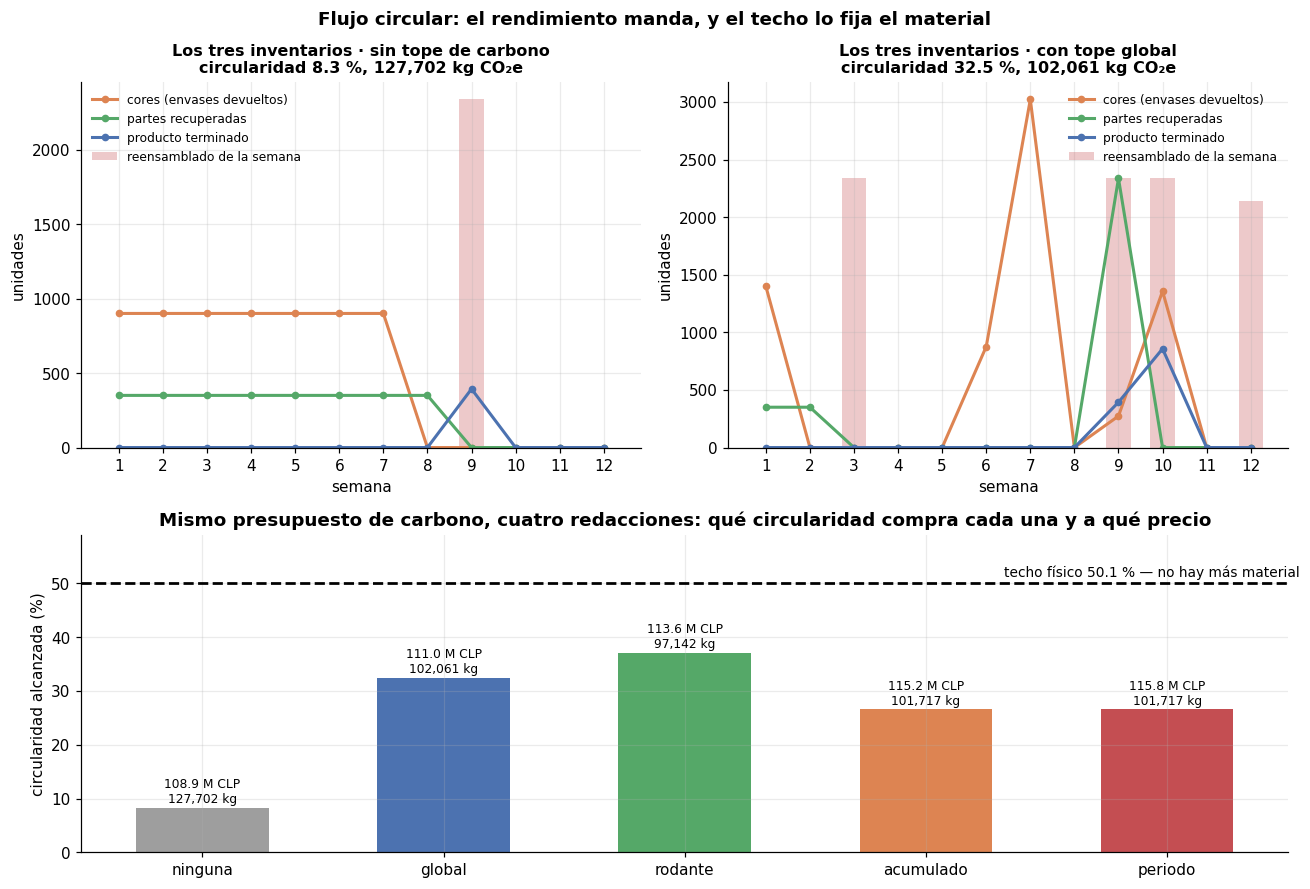

In [10]:
fig = plt.figure(figsize=(12.0, 8.2))
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1])
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

cols = {"C": "#dd8452", "P": "#55a868", "S": "#4c72b0"}
etiq = {"C": "cores (envases devueltos)", "P": "partes recuperadas",
        "S": "producto terminado"}
for ax, pol, titulo in ((ax_a, "ninguna", "sin tope de carbono"),
                        (ax_b, "global", "con tope global")):
    for k in ("C", "P", "S"):
        ax.plot(T, [sol[pol][k][t].X for t in T], color=cols[k], lw=2.0,
                marker="o", ms=4, label=etiq[k])
    ax.bar(T, [sol[pol]["x"][t].X for t in T], 0.55, color="#c44e52", alpha=0.30,
           label="reensamblado de la semana")
    ax.set_xticks(T)
    ax.set_xlabel("semana")
    ax.set_ylabel("unidades")
    ax.set_title(f"Los tres inventarios · {titulo}\n"
                 f"circularidad {100*res[pol]['circularidad']:.1f} %, "
                 f"{res[pol]['CO2e']:,.0f} kg CO₂e", fontsize=10.5)
    ax.legend(fontsize=8)

colores = {"ninguna": "#9e9e9e", "global": "#4c72b0", "rodante": "#55a868",
           "acumulado": "#dd8452", "periodo": "#c44e52"}
xx = np.arange(len(POLITICAS))
barras = ax_c.bar(xx, [tabla_pol.loc[p, "circularidad"] for p in POLITICAS],
                  0.55, color=[colores[p] for p in POLITICAS])
ax_c.axhline(100 * techo, color="black", ls="--", lw=1.8)
ax_c.text(len(POLITICAS) - 0.45, 100 * techo + 1.2,
          f"techo físico {100*techo:.1f} % — no hay más material",
          ha="right", fontsize=9)
for b, pol in zip(barras, POLITICAS):
    ax_c.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.0,
              f"{tabla_pol.loc[pol,'objetivo']/1e6:,.1f} M CLP\n"
              f"{tabla_pol.loc[pol,'CO2e']:,.0f} kg", ha="center", fontsize=8)
ax_c.set_xticks(xx)
ax_c.set_xticklabels(POLITICAS)
ax_c.set_ylim(0, 100 * techo + 9)
ax_c.set_ylabel("circularidad alcanzada (%)")
ax_c.set_title("Mismo presupuesto de carbono, cuatro redacciones: "
               "qué circularidad compra cada una y a qué precio")
fig.suptitle("Flujo circular: el rendimiento manda, y el techo lo fija el material",
             fontweight="bold")
figura(fig, "reman_inventarios")
plt.show()

## 7. Comprobación

Además de las cifras de referencia, se recalculan los tres balances desde la
**solución**, con especial atención al de partes: es el que se equivoca. Si el
modelo hubiera aplicado $\rho$ al período equivocado, el residuo que se
calcula aquí —que usa $\rho_{t-L}\,u_{t-L}$ leído de los datos originales— no
daría cero.

In [11]:
print("Comprobación:")
ok = []
ok.append(verificar(costo_circular, 3_250.0, "costo por core procesado (CLP)"))
ok.append(verificar(100 * (costo_circular / C_NUEVO - 1), -15.6,
                    "ventaja ingenua vs. nuevo (%)", tol=5e-3))
ok.append(verificar(costo_entregado_red, 4_167.0,
                    "costo por envase entregado, rho = 0,78 (CLP)", tol=1e-3))
ok.append(verificar(100 * (costo_entregado_red / C_NUEVO - 1), 8.2,
                    "desventaja real vs. nuevo, rho = 0,78 (%)", tol=1e-2))
ok.append(verificar(costo_entregado, 4_189.9,
                    "costo por envase entregado, rho exacto (CLP)", tol=1e-3))
ok.append(verificar((C_ACEPTAR + C_DESENS) / rho_medio + C_RECUP + C_REENS,
                    3_527.6, "costo por envase entregado, por etapas (CLP)",
                    tol=1e-3))
ok.append(verificar(rho_critico, 0.6154, "rendimiento crítico por etapas",
                    tol=1e-3))
ok.append(verificar(100 * techo, 50.1, "techo físico de circularidad (%)", tol=1e-3))
ok.append(verificar(PRESUPUESTO, 102_161.0, "presupuesto de carbono (kg)", tol=1e-6))
ok.append(verificar(c["ninguna"], 108_887_417.0, "sin política (CLP)", tol=1e-5))
ok.append(verificar(c["global"], 111_008_862.0, "política global (CLP)", tol=1e-5))
ok.append(verificar(c["rodante"], 113_622_519.0, "política rodante (CLP)", tol=1e-5))
ok.append(verificar(c["acumulado"], 115_220_635.0, "política acumulada (CLP)", tol=1e-5))
ok.append(verificar(c["periodo"], 115_752_024.0, "política por período (CLP)", tol=1e-5))
ok.append(verificar(100 * res["ninguna"]["circularidad"], 8.3,
                    "circularidad sin política (%)", tol=1e-2))
ok.append(verificar(100 * res["rodante"]["circularidad"], 37.0,
                    "circularidad con política rodante (%)", tol=1e-2))

# balances recalculados desde la solucion del plan con tope global
peorC = peorP = peorS = 0.0
vg = sol["global"]
for k, t in enumerate(T):
    prevC = INV0["C"] if k == 0 else vg["C"][T[k - 1]].X
    prevP = INV0["P"] if k == 0 else vg["P"][T[k - 1]].X
    prevS = INV0["S"] if k == 0 else vg["S"][T[k - 1]].X
    llega = (rendimiento[T[k - L]] * vg["u"][T[k - L]].X) if k - L >= 0 else 0.0
    peorC = max(peorC, abs(prevC + vg["a"][t].X - vg["u"][t].X - vg["w"][t].X
                           - vg["C"][t].X))
    peorP = max(peorP, abs(prevP + llega - vg["v"][t].X - vg["P"][t].X))
    peorS = max(peorS, abs(prevS + vg["x"][t].X + vg["m"][t].X - demanda[t]
                           + vg["l"][t].X - vg["S"][t].X))
ok.append(verificar(peorC, 0.0, "residuo del balance de cores", tol=1e-5))
ok.append(verificar(peorP, 0.0, "residuo del balance de partes", tol=1e-5))
ok.append(verificar(peorS, 0.0, "residuo del balance de producto", tol=1e-5))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

assert orden_ok, "el anidamiento de las políticas de carbono no se cumple"
assert all(res[p]["estado"] == "OPTIMAL" for p in res)
assert max(res[p]["circularidad"] for p in res) <= techo + 1e-9, \
    "ninguna política puede superar el techo físico"
assert peorC < 1e-5 and peorP < 1e-5 and peorS < 1e-5
for p in POLITICAS[1:]:
    assert res[p]["CO2e"] <= PRESUPUESTO * (1 + 1e-6), \
        f"la política {p} excede el presupuesto"

tabla(plan0, "reman_plan_sin_tope")
tabla(tabla_pol.reset_index().rename(columns={"index": "politica"}),
      "reman_politicas")
perfiles = pd.DataFrame({
    "t": T,
    "cores_global": [sol["global"]["C"][t].X for t in T],
    "partes_global": [sol["global"]["P"][t].X for t in T],
    "producto_global": [sol["global"]["S"][t].X for t in T],
    "reensamblado_global": [sol["global"]["x"][t].X for t in T],
    "nuevos_global": [sol["global"]["m"][t].X for t in T]})
tabla(perfiles, "reman_perfiles")
resumen({"costo_por_core_procesado": float(costo_circular),
         "costo_por_envase_entregado": float(costo_entregado),
         "rho_medio": float(rho_medio), "rho_critico": float(rho_critico),
         "techo_circularidad_pct": float(100 * techo),
         "presupuesto_kgco2e": float(PRESUPUESTO),
         "costos": {k: float(v) for k, v in c.items()},
         "circularidad_pct": {k: float(tabla_pol.loc[k, "circularidad"])
                              for k in POLITICAS},
         "co2e": {k: float(tabla_pol.loc[k, "CO2e"]) for k in POLITICAS}},
        "resumen_remanufactura")
print("Guardado en resultados/")

Comprobación:
  [  OK  ] costo por core procesado (CLP): obtenido 3,250.0000 | referencia 3,250.0000 | dif. relativa 0.00e+00
  [  OK  ] ventaja ingenua vs. nuevo (%): obtenido -15.5844 | referencia -15.6000 | dif. relativa 9.99e-04
  [  OK  ] costo por envase entregado, rho = 0,78 (CLP): obtenido 4,166.6667 | referencia 4,167.0000 | dif. relativa 8.00e-05
  [  OK  ] desventaja real vs. nuevo, rho = 0,78 (%): obtenido 8.2251 | referencia 8.2000 | dif. relativa 3.06e-03
  [  OK  ] costo por envase entregado, rho exacto (CLP): obtenido 4,189.9273 | referencia 4,189.9000 | dif. relativa 6.51e-06
  [  OK  ] costo por envase entregado, por etapas (CLP): obtenido 3,527.6401 | referencia 3,527.6000 | dif. relativa 1.14e-05
  [  OK  ] rendimiento crítico por etapas: obtenido 0.6154 | referencia 0.6154 | dif. relativa 1.54e-05
  [  OK  ] techo físico de circularidad (%): obtenido 50.0711 | referencia 50.1000 | dif. relativa 5.77e-04
  [  OK  ] presupuesto de carbono (kg): obtenido 102,161.0000 

---

## Para llevarse

1. **El rendimiento va en el denominador, y hay que saber QUÉ va arriba.**
   3 250 contra 3 850 es −15,6 % y es la comparación equivocada, porque compara
   un core que entra con un envase que sirve. Dividiendo todo por ρ ≈ 0,78 son
   4 167, o sea +8,2 %, y el negocio se da vuelta. Dividiendo solo lo que se
   paga por core que entra —que es lo que implementa el modelo— son 3 528, o
   sea −8,4 %, y vuelve a convenir. Las dos cuentas son correctas para dos
   procesos distintos: la pregunta no es aritmética, es en qué punto de la
   línea se descarta el material.
2. **El techo de la circularidad es físico y se calcula antes de optimizar.**
   Retornos × ρ cubren el 50,1 % de la demanda. Ninguna política, ningún
   impuesto y ningún presupuesto pasa de ahí, porque no hay más material.
   Llevar ese número a la reunión ahorra la discusión sobre la meta del 80 %.
3. **ρ multiplica el flujo de hace L períodos, no el de ahora.** Es el error
   clásico y es silencioso: el modelo resuelve, dice `OPTIMAL` y entrega un
   plan que la planta no puede ejecutar. La comprobación de la sección 7
   recalcula ese balance desde los datos originales precisamente por eso.
4. **Aceptar un core es una decisión, no un dato.** Sin tope de carbono el
   plan rechaza más del 90 % de los retornos, porque un core que no se va a
   procesar es puro costo de aceptación y de bodega.
5. **La circularidad es cara en pesos y barata en carbono.** Por eso el tope
   la sube de 8 % a 37 % y el costo sube 4,3 %. Un tope de carbono no es un
   impuesto ni una meta de circularidad, pero termina comprando circularidad:
   conviene saber cuánto paga por ella antes de escribir la norma.

## Ejercicios

1. Suba el rendimiento de todas las semanas en 5 puntos porcentuales y vuelva
   a correr el plan sin tope. ¿Cuánto sube la circularidad? Contraste el
   resultado con el $\rho^*$ crítico de la sección 1 y explique por qué el
   salto no es proporcional.
2. Elimine el lead time (`lead_time=False`) y compare el plan con el de este
   cuaderno. ¿Cuánto baja el costo? Ese número es lo que la planta ganaría si
   el desensamble entregara partes el mismo día: úselo para decidir si vale la
   pena invertir en acortarlo.
3. Reemplace el tope global por un **impuesto** de τ CLP por kg CO₂e sumado al
   objetivo. Busque el τ que produce exactamente 102 161 kg de emisión.
   ¿El plan resultante es el mismo que el de la política global? ¿Y el costo
   para la planta, contando el impuesto pagado?